# News Intelligence NLP

## NLP-based classification of news articles into World, Sports, Business, and Sci/Tech categories using TF-IDF and machine learning.

## 1. Data Loading and Initial Inspection

### Load the news dataset and perform basic structural and data quality checks.

In [1]:
import pandas as pd 

In [2]:
train_df = pd.read_csv('train.csv')

train_df.head()

In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 29.7 MB


## 2. Exploratory Data Analysis

### Explore the dataset structure, class distribution, and basic text characteristics.

In [4]:
train_df.columns

Index(['Class Index', 'Title', 'Description'], dtype='str')

In [5]:
train_df.shape

(120000, 3)

In [6]:
train_df.isnull()

,Class Index,Title,Description
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
119995,False,False,False
119996,False,False,False
119997,False,False,False
119998,False,False,False


In [7]:
train_df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [8]:
train_df.duplicated().sum()

np.int64(0)

In [9]:
train_df["Class Index"].value_counts().sort_index()

Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64

In [10]:
train_df["Class Index"].value_counts(normalize=True).sort_index() * 100

Class Index
1    25.0
2    25.0
3    25.0
4    25.0
Name: proportion, dtype: float64

In [11]:
train_df

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


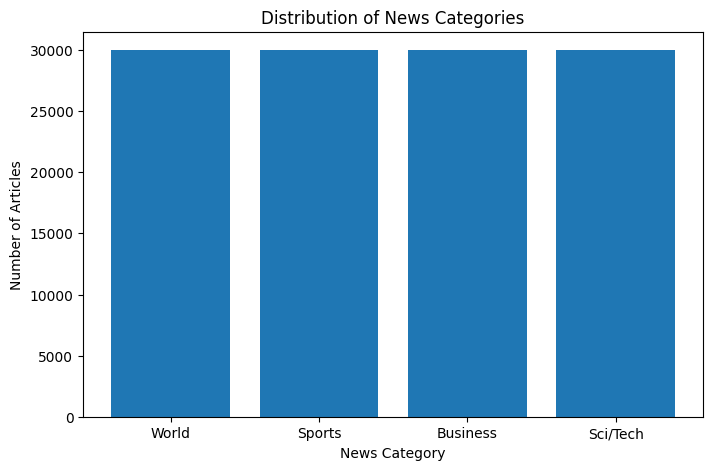

In [12]:
import matplotlib.pyplot as plt

class_counts = train_df["Class Index"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.title("Distribution of News Categories")

plt.xticks([1, 2, 3, 4], ["World", "Sports", "Business", "Sci/Tech"])

plt.show()

In [13]:
train_df["title_length"] = train_df["Title"].str.len()

In [14]:
train_df[["Title", "title_length"]].head()

,Title,title_length
0,Wall St. Bears Claw Back Into the Black (Reuters),49
1,Carlyle Looks Toward Commercial Aerospace (Reu...,51
2,Oil and Economy Cloud Stocks' Outlook (Reuters),47
3,Iraq Halts Oil Exports from Main Southern Pipe...,60
4,"Oil prices soar to all-time record, posing new...",73


In [15]:
train_df["description_length"] = train_df["Description"].str.len()

In [16]:
train_df[["Description", "description_length"]].head()

,Description,description_length
0,"Reuters - Short-sellers, Wall Street's dwindli...",94
1,Reuters - Private investment firm Carlyle Grou...,214
2,Reuters - Soaring crude prices plus worries\ab...,184
3,Reuters - Authorities have halted oil export\f...,195
4,"AFP - Tearaway world oil prices, toppling reco...",160


In [17]:
train_df["title_length"].describe()

count    120000.000000
mean         42.071508
std          13.569405
min           6.000000
25%          33.000000
50%          41.000000
75%          49.000000
max         115.000000
Name: title_length, dtype: float64

In [18]:
train_df["description_length"].describe()

count    120000.000000
mean        193.388517
std          64.472066
min           6.000000
25%         155.000000
50%         188.000000
75%         219.000000
max         985.000000
Name: description_length, dtype: float64

In [19]:
train_df["title_word_count"] = train_df["Title"].str.split().str.len()

In [20]:
train_df[["Title", "title_word_count"]].head()

,Title,title_word_count
0,Wall St. Bears Claw Back Into the Black (Reuters),9
1,Carlyle Looks Toward Commercial Aerospace (Reu...,6
2,Oil and Economy Cloud Stocks' Outlook (Reuters),7
3,Iraq Halts Oil Exports from Main Southern Pipe...,9
4,"Oil prices soar to all-time record, posing new...",13


In [21]:
train_df["description_word_count"] = train_df["Description"].str.split().str.len()

In [22]:
train_df[["Description", "description_word_count"]].head()

,Description,description_word_count
0,"Reuters - Short-sellers, Wall Street's dwindli...",12
1,Reuters - Private investment firm Carlyle Grou...,30
2,Reuters - Soaring crude prices plus worries\ab...,29
3,Reuters - Authorities have halted oil export\f...,27
4,"AFP - Tearaway world oil prices, toppling reco...",24


In [23]:
train_df["title_word_count"].describe()

count    120000.000000
mean          6.784108
std           2.088201
min           1.000000
25%           5.000000
50%           7.000000
75%           8.000000
max          19.000000
Name: title_word_count, dtype: float64

In [24]:
train_df["description_word_count"].describe()

count    120000.000000
mean         31.060508
std           9.760460
min           1.000000
25%          25.000000
50%          30.000000
75%          36.000000
max         173.000000
Name: description_word_count, dtype: float64

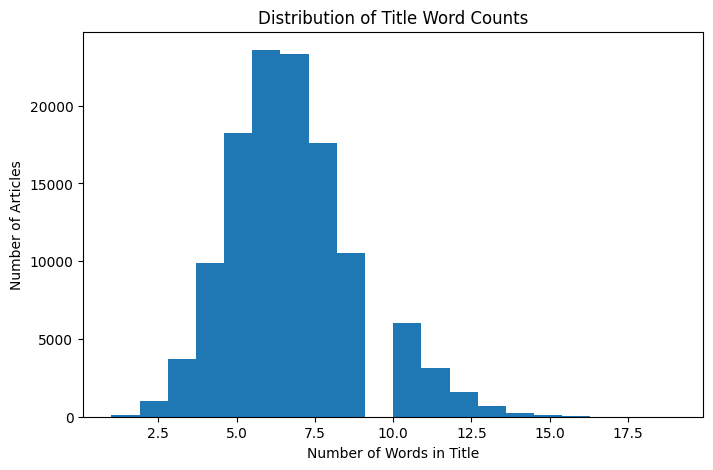

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["title_word_count"], bins=20)

plt.xlabel("Number of Words in Title")
plt.ylabel("Number of Articles")
plt.title("Distribution of Title Word Counts")

plt.show()

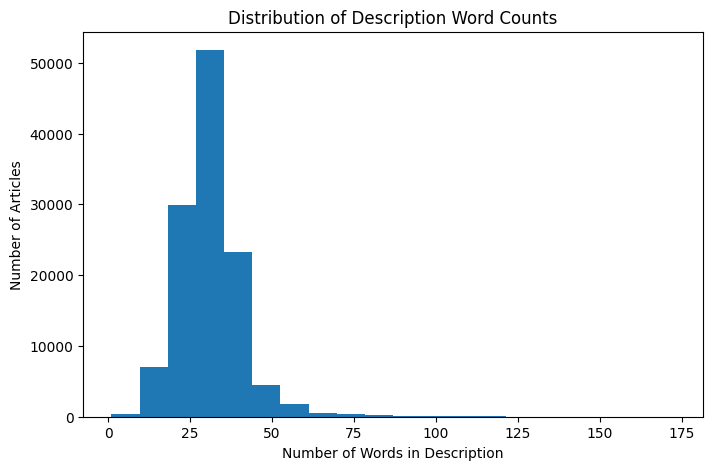

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(train_df["description_word_count"], bins=20)

plt.xlabel("Number of Words in Description")
plt.ylabel("Number of Articles")
plt.title("Distribution of Description Word Counts")

plt.show()

In [27]:
train_df.sample(5)

,Class Index,Title,Description,title_length,description_length,title_word_count,description_word_count
778,1,"Journalist, Translator Missing in Iraq (AP)",AP - A French-American journalist has disappea...,43,166,6,25
61413,1,U.K. Judge: Bankers May Be Extradited (AP),AP - A judge ruled Friday that three British b...,42,157,7,27
15947,4,SCO to cap legal expenses,"The SCO Group, committed to an expensive legal...",25,200,5,34
53298,2,India still in the game: Harbhajan,"Harbhajan Singh, who claimed five wickets in A...",34,205,6,35
69498,1,Latest kidnapping angers many Iraqis,Kidnapped aid worker Margaret Hassan pleaded f...,36,155,5,25


In [28]:
train_df["Description"].str.contains(r"\d", regex=True).sum()

np.int64(63070)

In [29]:
import string

In [30]:
train_df["Description"].str.contains(
    f"[{string.punctuation}]",
    regex=True
).sum()

np.int64(119673)

## 3. Text Preprocessing

### Clean and normalize the news text before feature extraction.

In [31]:
train_df["Description"].str.contains("Reuters", case=False, regex=False).sum()

np.int64(12956)

In [32]:
train_df["article_text"] = train_df["Title"] + " " + train_df["Description"]

In [33]:
train_df[["Title", "Description", "article_text"]].head()

,Title,Description,article_text
0,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [34]:
import re

def normalize_whitespace(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [35]:
train_df["article_text_clean"] = train_df["article_text"].apply(normalize_whitespace)

In [36]:
train_df[["article_text", "article_text_clean"]].head()

,article_text,article_text_clean
0,Wall St. Bears Claw Back Into the Black (Reute...,Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new...","Oil prices soar to all-time record, posing new..."


In [37]:
train_df["article_text_lower"] = train_df["article_text_clean"].str.lower()

In [38]:
train_df[["article_text_clean", "article_text_lower"]].head()

,article_text_clean,article_text_lower
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st. bears claw back into the black (reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace (reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil and economy cloud stocks' outlook (reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports from main southern pipe...
4,"Oil prices soar to all-time record, posing new...","oil prices soar to all-time record, posing new..."


In [39]:
from collections import Counter
import string

punctuation_counts = Counter(
    char
    for text in train_df["article_text_lower"]
    for char in text
    if char in string.punctuation
)

punctuation_counts.most_common(20)

[('.', 225935),
 (',', 165668),
 ('-', 139159),
 (';', 87360),
 ('#', 47307),
 ('(', 41089),
 (')', 40770),
 ("'", 32235),
 ('\\', 26977),
 ('&', 26323),
 (':', 21517),
 ('/', 20990),
 ('"', 13035),
 ('$', 10976),
 ('=', 8440),
 ('?', 5723),
 ('!', 846),
 ('_', 198),
 ('*', 152)]

In [40]:
source_patterns = ["Reuters", "AFP"]

for source in source_patterns:
    count = train_df["article_text_lower"].str.contains(
        source.lower(),
        regex=False
    ).sum()
    
    print(f"{source}: {count} articles")

Reuters: 12970 articles
AFP: 2549 articles


In [41]:
reuters_examples = train_df[
    train_df["article_text_lower"].str.contains("reuters", regex=False)
]["article_text_lower"].head(5)

reuters_examples

0    wall st. bears claw back into the black (reute...
1    carlyle looks toward commercial aerospace (reu...
2    oil and economy cloud stocks' outlook (reuters...
3    iraq halts oil exports from main southern pipe...
5    stocks end up, but near year lows (reuters) re...
Name: article_text_lower, dtype: str

In [42]:
print(train_df.loc[0, "article_text_lower"])

wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.


In [43]:
def remove_source_markers(text):
    text = re.sub(r"\(reuters\)", " ", text)
    text = re.sub(r"\breuters\s*-\s*", " ", text)
    text = re.sub(r"\(afp\)", " ", text)
    text = re.sub(r"\bafp\s*-\s*", " ", text)
    return text

In [44]:
test_text = train_df.loc[0, "article_text_lower"]

cleaned_test_text = remove_source_markers(test_text)

print("BEFORE:")
print(test_text)

print("\nAFTER:")
print(cleaned_test_text)

BEFORE:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

AFTER:
wall st. bears claw back into the black    short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.


In [45]:
backslash_b_count = train_df["article_text_lower"].str.contains(
    r"\\b",
    regex=True
).sum()

print("Articles containing '\\b':", backslash_b_count)

Articles containing '\b': 595


In [46]:
backslash_b_examples = train_df[
    train_df["article_text_lower"].str.contains(
        r"\\b",
        regex=True
    )
]["article_text_lower"].head(5)

for i, text in backslash_b_examples.items():
    print(f"\n--- Article {i} ---")
    print(text)


--- Article 0 ---
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

--- Article 5 ---
stocks end up, but near year lows (reuters) reuters - stocks ended slightly higher on friday\but stayed near lows for the year as oil prices surged past #36;46\a barrel, offsetting a positive outlook from computer maker\dell inc. (dell.o)

--- Article 84 ---
european download services go mobile (reuters) reuters - the ability to download complete\tracks directly over cell-phone networks to mobile phones is\becoming a reality in europe.

--- Article 94 ---
t. rex had teen growth spurt, scientists say (reuters) reuters - tyrannosaurus rex grew incredibly fast\during a teenaged growth spurt that saw the dinosaur expand its\bulk by six times, but the fearsome beasts "lived fast and died\young," researchers said on wednesday.

--- Article 98 ---
uk scientists allowed to clone human embryos (reuters) reuters - b

In [47]:
test_text_fixed = re.sub(r"\\b", " ", test_text)

print("BEFORE:")
print(test_text)

print("\nAFTER:")
print(test_text_fixed)

BEFORE:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

AFTER:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling and of ultra-cynics, are seeing green again.


In [48]:
def clean_article_text(text):
    # Remove source markers
    text = re.sub(r"\(reuters\)", " ", text)
    text = re.sub(r"\breuters\s*-\s*", " ", text)
    text = re.sub(r"\(afp\)", " ", text)
    text = re.sub(r"\bafp\s*-\s*", " ", text)

    # Replace the dataset's \b artifact with a space
    text = re.sub(r"\\b", " ", text)

    # Normalize whitespace again
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [49]:
test_cleaned = clean_article_text(test_text)

print("BEFORE:")
print(test_text)

print("\nAFTER:")
print(test_cleaned)

BEFORE:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

AFTER:
wall st. bears claw back into the black short-sellers, wall street's dwindling and of ultra-cynics, are seeing green again.


In [50]:
print(repr(train_df.loc[0, "article_text_lower"]))

"wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\\band of ultra-cynics, are seeing green again."


In [51]:
test_text_fixed = re.sub(r"\\", " ", test_text)

print("BEFORE:")
print(test_text)

print("\nAFTER:")
print(test_text_fixed)

BEFORE:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling\band of ultra-cynics, are seeing green again.

AFTER:
wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling band of ultra-cynics, are seeing green again.


In [52]:
def clean_article_text(text):
    # Remove source markers
    text = re.sub(r"\(reuters\)", " ", text)
    text = re.sub(r"\breuters\s*-\s*", " ", text)
    text = re.sub(r"\(afp\)", " ", text)
    text = re.sub(r"\bafp\s*-\s*", " ", text)

    # Replace dataset backslash artifacts with a space
    text = re.sub(r"\\", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [53]:
train_df["clean_text"] = train_df["article_text_lower"].apply(clean_article_text)

In [54]:
train_df[["article_text_lower", "clean_text"]].head()

,article_text_lower,clean_text
0,wall st. bears claw back into the black (reute...,wall st. bears claw back into the black short-...
1,carlyle looks toward commercial aerospace (reu...,carlyle looks toward commercial aerospace priv...
2,oil and economy cloud stocks' outlook (reuters...,oil and economy cloud stocks' outlook soaring ...
3,iraq halts oil exports from main southern pipe...,iraq halts oil exports from main southern pipe...
4,"oil prices soar to all-time record, posing new...","oil prices soar to all-time record, posing new..."


## 4. TF-IDF Feature Extraction

### Convert the cleaned text into numerical features using TF-IDF.

In [55]:
print(
    "Reuters remaining:",
    train_df["clean_text"].str.contains("reuters", regex=False).sum()
)

print(
    "AFP remaining:",
    train_df["clean_text"].str.contains("afp", regex=False).sum()
)

Reuters remaining: 1914
AFP remaining: 72


In [56]:
print(
    "Backslashes remaining:",
    train_df["clean_text"].str.contains(r"\\", regex=True).sum()
)

Backslashes remaining: 0


In [57]:
reuters_remaining_examples = train_df[
    train_df["clean_text"].str.contains("reuters", regex=False)
]["clean_text"].head(5)

for i, text in reuters_remaining_examples.items():
    print(f"\n--- Article {i} ---")
    print(text)


--- Article 620 ---
funds: are bond funds hazardous? (clint willis is a freelance writer who covers mutual funds for reuters. any opinions in the column are solely those of mr. willis.)

--- Article 837 ---
darfur displaced return to 'live in fear' of militia villagers returning to their homes in sudan's darfur region are living in fear of the arab militiamen who initially drove them away, the united nations said in a report received by reuters monday.

--- Article 839 ---
darfur displaced return to 'live in fear' of militia khartoum, sudan - villagers returning to their homes in sudan's darfur region are living in fear of the arab militiamen who initially drove them away, the united nations said in a report received by reuters monday.

--- Article 961 ---
kmart posts profit; cash hits $2.6 bln chicago - kmart holdings corp. &lt;a href="http://www.investor.reuters.com/fullquote.aspx?ticker=kmrt.o target=/stocks/quickinfo/fullquote"&gt;kmrt.o&lt;/a&gt; on monday reported its third cons

In [58]:
import nltk
from nltk.tokenize import word_tokenize

In [59]:
sample_text = train_df.loc[0, "clean_text"]

tokens = word_tokenize(sample_text)

print(tokens[:30])

['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', 'short-sellers', ',', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', ',', 'are', 'seeing', 'green', 'again', '.']


In [60]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [61]:
sample_text = train_df.loc[0, "clean_text"]

tokens = word_tokenize(sample_text)

print(tokens[:30])

['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', 'short-sellers', ',', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', ',', 'are', 'seeing', 'green', 'again', '.']


In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

In [64]:
X = train_df["clean_text"]
y = train_df["Class Index"]

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [67]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation class distribution:")
print(y_valid.value_counts(normalize=True).sort_index())

Training samples: 96000
Validation samples: 24000

Training class distribution:
Class Index
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64

Validation class distribution:
Class Index
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64


In [68]:
X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (96000, 50000)


In [69]:
X_valid_tfidf = tfidf.transform(X_valid)

print("Validation TF-IDF shape:", X_valid_tfidf.shape)

Validation TF-IDF shape: (24000, 50000)


In [70]:
from sklearn.linear_model import LogisticRegression

## 5. Model Training

### Train Logistic Regression and Linear SVM models using the TF-IDF features.

In [71]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [72]:
y_pred = logistic_model.predict(X_valid_tfidf)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 24000


## 6. Model Evaluation

### Evaluate the models using accuracy, precision, recall, F1-score, and classification reports.

In [73]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [74]:
accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred, average="weighted")
recall = recall_score(y_valid, y_pred, average="weighted")
f1 = f1_score(y_valid, y_pred, average="weighted")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9200
Precision: 0.9198
Recall   : 0.9200
F1-Score : 0.9198


In [75]:
from sklearn.metrics import classification_report

In [76]:
print(classification_report(
    y_valid,
    y_pred,
    target_names=["World", "Sports", "Business", "Sci/Tech"]
))

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      6000
      Sports       0.95      0.98      0.97      6000
    Business       0.89      0.89      0.89      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



In [77]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
cm = confusion_matrix(y_valid, y_pred)

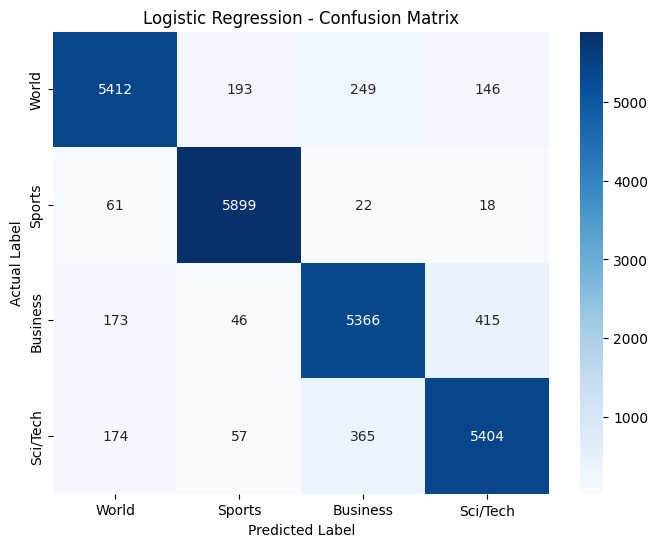

In [79]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["World", "Sports", "Business", "Sci/Tech"],
    yticklabels=["World", "Sports", "Business", "Sci/Tech"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [80]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [81]:
y_pred_svm = svm_model.predict(X_valid_tfidf)

print("SVM predictions generated successfully.")
print("Number of predictions:", len(y_pred_svm))

SVM predictions generated successfully.
Number of predictions: 24000


In [82]:
accuracy_svm = accuracy_score(y_valid, y_pred_svm)
precision_svm = precision_score(y_valid, y_pred_svm, average="weighted")
recall_svm = recall_score(y_valid, y_pred_svm, average="weighted")
f1_svm = f1_score(y_valid, y_pred_svm, average="weighted")

In [83]:
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

Accuracy : 0.9204
Precision: 0.9202
Recall   : 0.9204
F1-Score : 0.9202


In [84]:
print(classification_report(
    y_valid,
    y_pred_svm,
    target_names=["World", "Sports", "Business", "Sci/Tech"]
))

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.90      0.89      0.89      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



## 7. Final Test Evaluation

### Evaluate the selected Linear SVM model on the unseen test dataset.

In [85]:
test_df = pd.read_csv(
    "test.csv",
    header=None,
    names=["Class Index", "Title", "Description"]
)

print("Test dataset shape:", test_df.shape)
print(test_df.head())

Test dataset shape: (7601, 3)
   Class Index                                              Title  \
0  Class Index                                              Title   
1            3                  Fears for T N pension after talks   
2            4  The Race is On: Second Private Team Sets Launc...   
3            4      Ky. Company Wins Grant to Study Peptides (AP)   
4            4      Prediction Unit Helps Forecast Wildfires (AP)   

                                         Description  
0                                        Description  
1  Unions representing workers at Turner   Newall...  
2  SPACE.com - TORONTO, Canada -- A second\team o...  
3  AP - A company founded by a chemistry research...  
4  AP - It's barely dawn when Mike Fitzpatrick st...  


In [86]:
test_df = pd.read_csv("test.csv")

print("Test dataset shape:", test_df.shape)
print(test_df.head())

Test dataset shape: (7600, 3)
   Class Index                                              Title  \
0            3                  Fears for T N pension after talks   
1            4  The Race is On: Second Private Team Sets Launc...   
2            4      Ky. Company Wins Grant to Study Peptides (AP)   
3            4      Prediction Unit Helps Forecast Wildfires (AP)   
4            4        Calif. Aims to Limit Farm-Related Smog (AP)   

                                         Description  
0  Unions representing workers at Turner   Newall...  
1  SPACE.com - TORONTO, Canada -- A second\team o...  
2  AP - A company founded by a chemistry research...  
3  AP - It's barely dawn when Mike Fitzpatrick st...  
4  AP - Southern California's smog-fighting agenc...  


In [87]:
test_df["article_text"] = (
    test_df["Title"] + " " + test_df["Description"]
)

test_df["article_text_lower"] = test_df["article_text"].str.lower()

print(test_df["article_text_lower"].iloc[0])

fears for t n pension after talks unions representing workers at turner   newall say they are 'disappointed' after talks with stricken parent firm federal mogul.


In [88]:
test_df["clean_text"] = test_df["article_text_lower"].apply(clean_article_text)

print(test_df["clean_text"].iloc[0])

fears for t n pension after talks unions representing workers at turner newall say they are 'disappointed' after talks with stricken parent firm federal mogul.


In [89]:
X_test_tfidf = tfidf.transform(test_df["clean_text"])

print("Test TF-IDF shape:", X_test_tfidf.shape)

Test TF-IDF shape: (7600, 50000)


In [90]:
y_test_pred = svm_model.predict(X_test_tfidf)

print("Final test predictions generated successfully.")
print("Number of predictions:", len(y_test_pred))

Final test predictions generated successfully.
Number of predictions: 7600


In [91]:
accuracy_test = accuracy_score(
    test_df["Class Index"], 
    y_test_pred)

precision_test = precision_score(
    test_df["Class Index"],
    y_test_pred,
    average="weighted"
)
recall_test = recall_score(
    test_df["Class Index"],
    y_test_pred,
    average="weighted"
)
f1_test = f1_score(
    test_df["Class Index"],
    y_test_pred,
    average="weighted"
)

print(f"Final Test Accuracy : {accuracy_test:.4f}")
print(f"Final Test Precision: {precision_test:.4f}")
print(f"Final Test Recall   : {recall_test:.4f}")
print(f"Final Test F1-Score : {f1_test:.4f}")

Final Test Accuracy : 0.9184
Final Test Precision: 0.9183
Final Test Recall   : 0.9184
Final Test F1-Score : 0.9183


In [92]:
print(classification_report(
    test_df["Class Index"],
    y_test_pred,
    target_names=["World", "Sports", "Business", "Sci/Tech"]
))

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.89      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



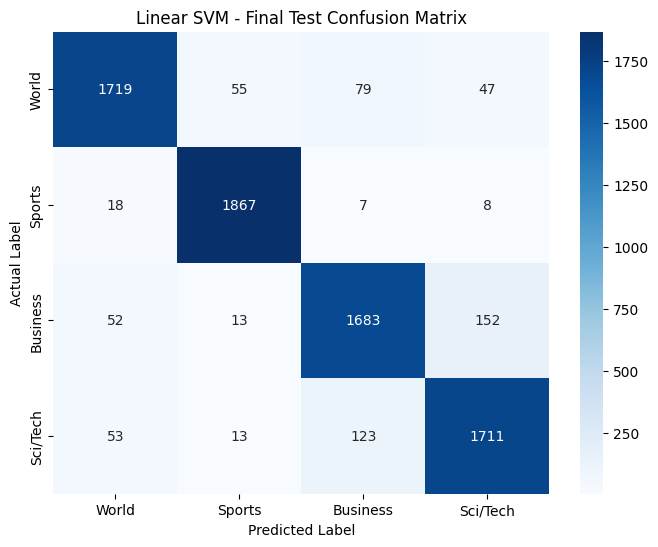

In [93]:
cm_test = confusion_matrix(
    test_df["Class Index"],
    y_test_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["World", "Sports", "Business", "Sci/Tech"],
    yticklabels=["World", "Sports", "Business", "Sci/Tech"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Linear SVM - Final Test Confusion Matrix")

plt.show()

## 8. Model Saving and Loading

### Save and reload the TF-IDF vectorizer and trained Linear SVM model for future predictions.

In [94]:
import joblib 

In [95]:
import os 

In [96]:
joblib.dump(tfidf, r"C:\Users\LENOVO\OneDrive\Documents\Work Project\News_Intelligence_NLP\models\tfidf_vectorizer.pkl")
joblib.dump(svm_model, r"C:\Users\LENOVO\OneDrive\Documents\Work Project\News_Intelligence_NLP\models\news_classifier_svm.pkl")

print("TF-IDF vectorizer saved successfully.")
print("Linear SVM model saved successfully.")

TF-IDF vectorizer saved successfully.
Linear SVM model saved successfully.


In [97]:
import joblib

loaded_tfidf = joblib.load(
    r"C:\Users\LENOVO\OneDrive\Documents\Work Project\News_Intelligence_NLP\models\tfidf_vectorizer.pkl"
)

loaded_svm = joblib.load(
    r"C:\Users\LENOVO\OneDrive\Documents\Work Project\News_Intelligence_NLP\models\news_classifier_svm.pkl"
)

print("TF-IDF vectorizer loaded successfully.")
print("Linear SVM model loaded successfully.")

TF-IDF vectorizer loaded successfully.
Linear SVM model loaded successfully.


## 9. News Category Prediction

### Use the trained model to predict categories for new news articles.

In [98]:
def predict_news(text):
    text = text.lower()
    text = clean_article_text(text)

    text_tfidf = loaded_tfidf.transform([text])

    prediction = loaded_svm.predict(text_tfidf)[0]

    category_map = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }

    return category_map[prediction]

In [99]:
sample_news = """India defeated Australia in the final match after a strong performance
from the batting and bowling teams."""

prediction = predict_news(sample_news)

print("Predicted Category:", prediction)

Predicted Category: Sports


In [100]:
test_news = [
    "The United Nations held an emergency meeting to discuss the ongoing international crisis.",
    "The company reported a significant increase in quarterly revenue and announced plans for expansion.",
    "The national football team won the championship after defeating its opponents in the final.",
    "Scientists developed a new artificial intelligence system that can improve medical diagnosis."
]

for news in test_news:
    print("News:", news)
    print("Predicted Category:", predict_news(news))
    print("-" * 80)

News: The United Nations held an emergency meeting to discuss the ongoing international crisis.
Predicted Category: World
--------------------------------------------------------------------------------
News: The company reported a significant increase in quarterly revenue and announced plans for expansion.
Predicted Category: Business
--------------------------------------------------------------------------------
News: The national football team won the championship after defeating its opponents in the final.
Predicted Category: Sports
--------------------------------------------------------------------------------
News: Scientists developed a new artificial intelligence system that can improve medical diagnosis.
Predicted Category: World
--------------------------------------------------------------------------------


In [101]:
sample_2 = " today AI being more advanded and moving towards ASI with advanced AI models"

prediction = predict_news(sample_2)

print("Predicted Category :", prediction)

Predicted Category : Sci/Tech


In [102]:
sample_3 = "In India the state tamilnadu had a new chief minister from a new party "

prediction = predict_news(sample_3)

print("New Predicted Category : ", prediction)

New Predicted Category :  World
